In [1]:
# Resstock model download, and ami optimization 

"""
Created on Sep 11 16:00:00 2025

@author: Tanushree Charan

"""

'\nCreated on Sep 11 16:00:00 2025\n\n@author: Tanushree Charan\n\n'

In [2]:
pip install awscli


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pyarrow fastparquet


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
!aws --version

aws-cli/1.42.0 Python/3.13.2 Darwin/25.4.0 botocore/1.40.0


In [5]:
pip install pandas


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
import subprocess
import zipfile
import os
import shutil
import json
import ast
import pandas as pd
from pathlib import Path

In [7]:
# SCRIPT TO READ AND SAVE ALL BUILDING IDS FROM THE NY METADATA FILE (FILTERED FOR DRYDEN RELEVANT COUNTIES)
# Read list of all building IDs

# path to metadata parquet

current_path = Path(os.getcwd())
data_path = current_path / '..'/ 'data' 
current_path = Path(os.getcwd())
data_path = current_path / '..'/ 'data' 
buildstock_metadata_path = '/Users/tcharan/Library/CloudStorage/OneDrive-NREL/NRELWorkPostJune2024/Projects/Grid Edge/FY25_Grid Edge/2025 ResStock/NY_upgrade0.xlsx'
# Read the "select_counties" sheet
df = pd.read_excel(buildstock_metadata_path, sheet_name="select_counties")

# Number of rows in the DataFrame
num_rows = len(df)
print("Number of rows:", num_rows)

building_ids_metadata = df["bldg_id"]

# Save building IDs to CSV
output_path = data_path / "base_files" / "building_ids_metadata_2025.csv"
building_ids_metadata.to_csv(output_path, index=False)

print("bldg_id count:", len(building_ids_metadata))
print(building_ids_metadata)
print('done')


Number of rows: 1516
bldg_id count: 1516
0          402
1          486
2          649
3         1387
4         1572
         ...  
1511    549227
1512    549378
1513    549749
1514    549921
1515    549976
Name: bldg_id, Length: 1516, dtype: int64
done


In [8]:
## CODE BLOCK AGGREGATE BUILDING METADATA WITH SELECTED RESSOTCK IDS

# Path to matched ReStock IDs
match_report_path = "/Users/tcharan/Documents/gh/buildstock-ami-mapping/output/match_report.csv"

# Read the matched resstock ID names
df_match = pd.read_csv(match_report_path)

# #meter id	ResStock_ids	cvrmses	cvrmses_month	percent_errs_cooling	percent_errs_heating	peak_htg_hr_diffs	peak_clg_hr_diffs	costs

# # For each ResStock ID, find the metadata from metadata df and create a new DF
# # --- Parse lists but keep duplicates ---
# def parse_ids(x):
#     if pd.isna(x):
#         return []
#     try:
#         arr = ast.literal_eval(str(x)) if isinstance(x, str) else []
#         return arr if isinstance(arr, list) else []
#     except Exception:
#         return []

# # Flatten all ResStock IDs, keeping duplicates
# resstock_ids_all = (
#     df_match_report['ResStock_ids']
#     .dropna()
#     .apply(parse_ids)
#     .explode()      # flatten lists
#     .dropna()
#     .astype(int)
#     .tolist()       # this keeps duplicates
# )

# print(f"Total ResStock IDs (with duplicates): {len(resstock_ids_all)}")
# # --- Print unique ResStock IDs ---
# unique_resstock_ids = sorted(set(resstock_ids_all))
# print(f"\nUnique ResStock IDs: {len(unique_resstock_ids)}")


# # --- Filter df by all IDs (with duplicates) ---
# df_metadata_all = df[df['bldg_id'].isin(resstock_ids_all)].copy()

# df_metadata_all.head()

# # Print total and unique bldg_id counts
# total_bldg_ids = df_metadata_all['bldg_id'].count()
# unique_bldg_ids = df_metadata_all['bldg_id'].nunique()

# print(f"Total bldg_id entries (including duplicates): {total_bldg_ids}")
# print(f"Unique bldg_id entries: {unique_bldg_ids}")

# --- 2. Parse ResStock_ids column ---
def parse_ids(x):
    if pd.isna(x): return []
    try:
        arr = ast.literal_eval(str(x)) if isinstance(x, str) else []
        return arr if isinstance(arr, list) else []
    except Exception:
        return []

# Flatten all ResStock IDs (keeping duplicates)
resstock_ids_all = (
    df_match['ResStock_ids']
    .dropna()
    .apply(parse_ids)
    .explode()
    .dropna()
    .astype(int)
)

print(f"Total ResStock IDs (including duplicates): {len(resstock_ids_all)}")

# --- 3. Directly merge each ID with its metadata ---
# Turn the ResStock IDs (with duplicates) into a DataFrame
df_resstock = pd.DataFrame({'bldg_id': resstock_ids_all})

# Merge — this automatically duplicates metadata for repeated IDs
df_metadata_weighted = df_resstock.merge(df, on='bldg_id', how='left')

# --- 4. Quick sanity checks ---
print(f"Final df_metadata_weighted rows: {len(df_metadata_weighted)}")
print(f"Unique bldg_ids: {df_metadata_weighted['bldg_id'].nunique()}")


Total ResStock IDs (including duplicates): 538
Final df_metadata_weighted rows: 538
Unique bldg_ids: 286


Saved: /Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_2025/heating_fuel_distribution.png


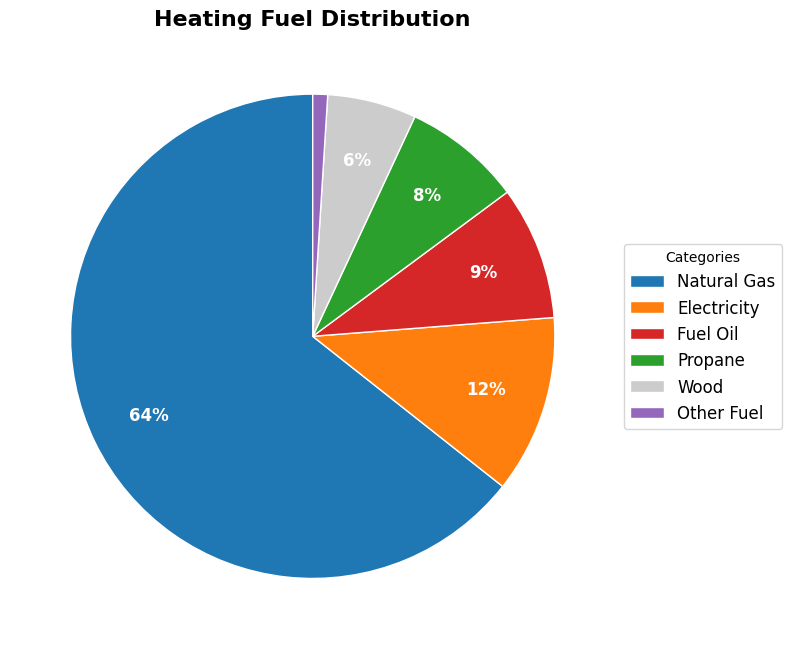


GrIDS HVAC Type Distribution:
    grids_hvac_type  count  percent
Natural Gas Furnace    254     47.4
 Other Fuel Furnace    112     20.9
 Natural Gas Boiler     92     17.2
Electric Resistance     48      9.0
      Electric ASHP     16      3.0
  Other Fuel Boiler     14      2.6
Saved table: /Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_2025/grids_hvac_type_distribution.csv
Saved: /Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_2025/grids_hvac_type_distribution.png


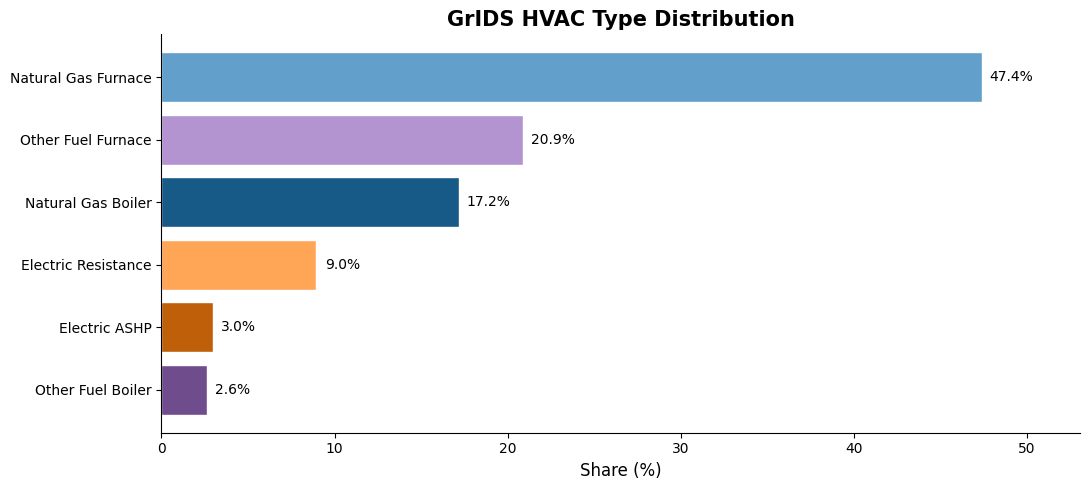

Saved: /Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_2025/cooling_type_distribution.png


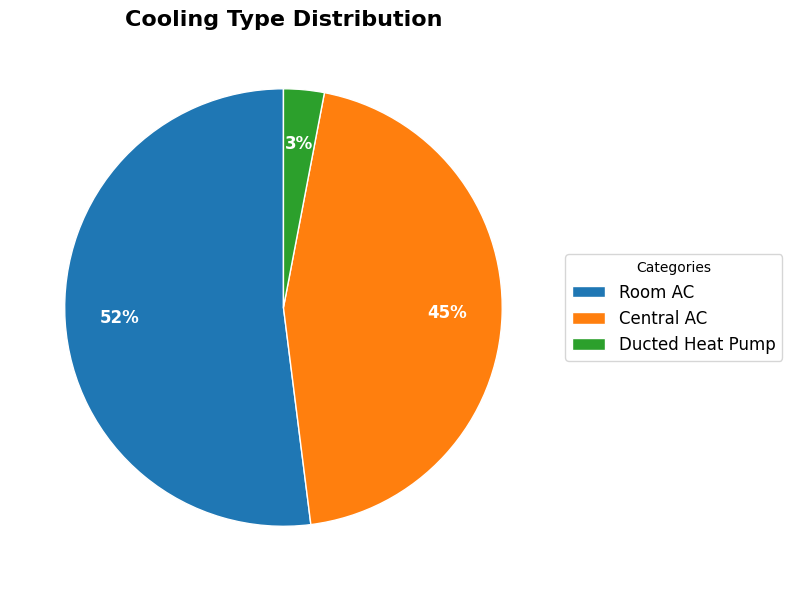

Saved: /Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_2025/building_type_recs_distribution.png


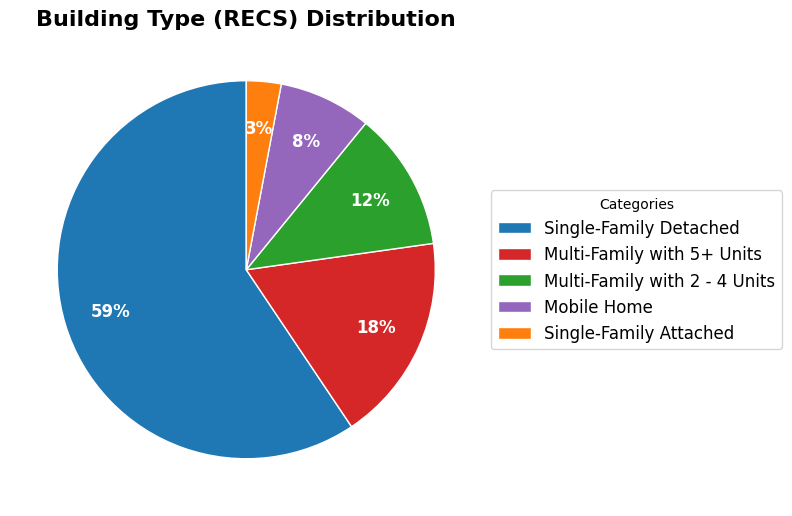

Saved: /Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_2025/building_vintage_distribution.png


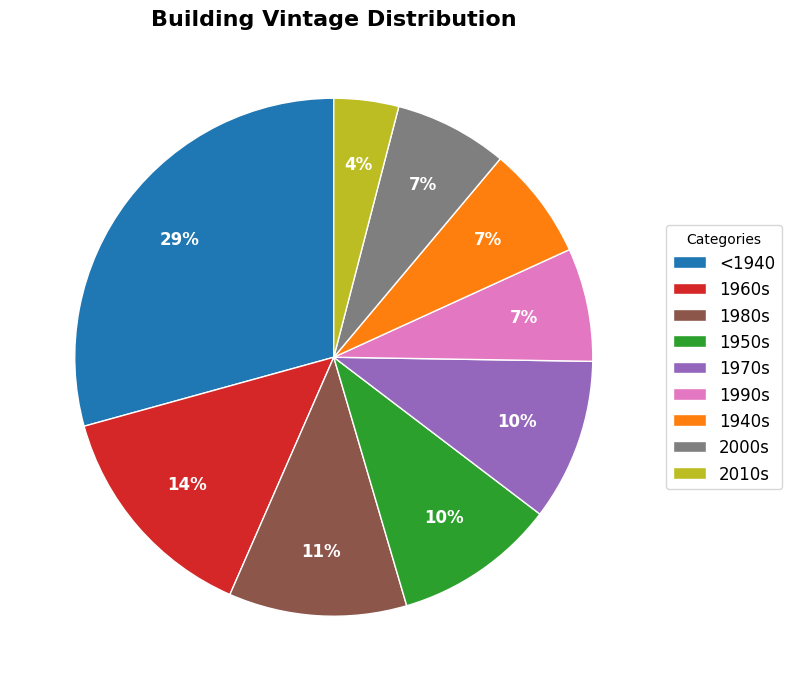

Saved: /Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_2025/domestic_hot_water_distribution.png


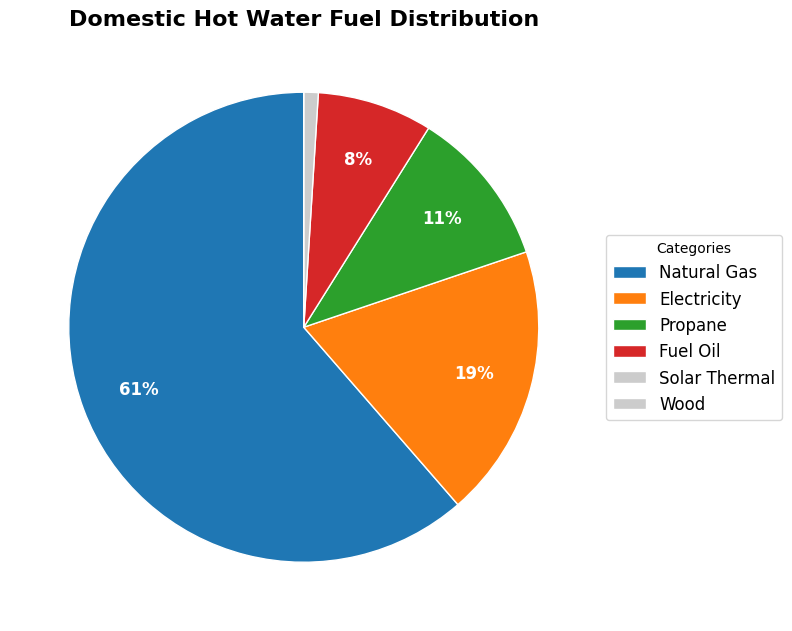


GrIDS Hot Water Type Distribution:
grids_hot_water_type  count  percent
         Natural Gas    333     61.9
          Other Fuel    101     18.8
 Electric Resistance    100     18.6
               Solar      3      0.6
  Electric Heat Pump      1      0.2
Saved table: /Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_2025/grids_hot_water_type_distribution.csv
Saved: /Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_2025/grids_hot_water_type_distribution.png


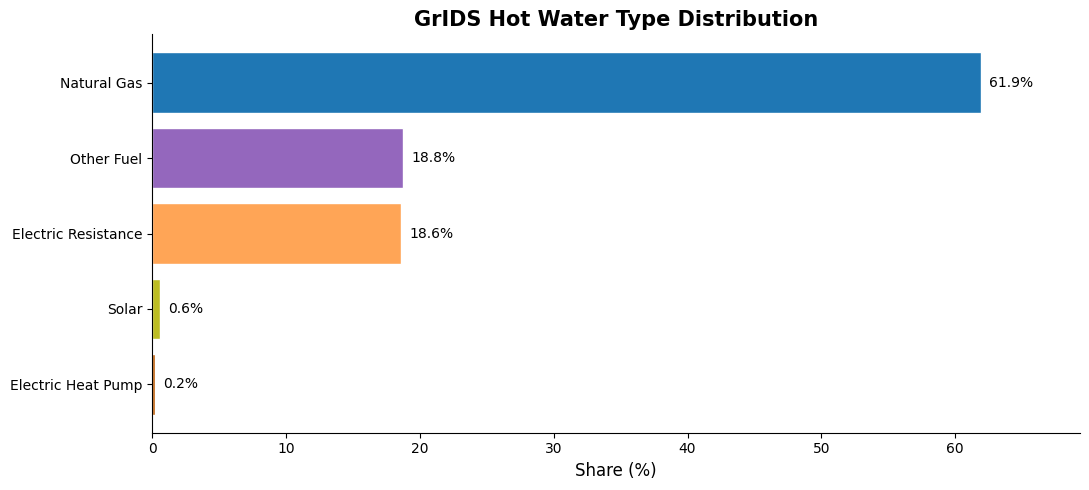

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Folder to save charts
output_dir = Path("/Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_2025")
output_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# FIXED COLOR MAPS (for pie charts)
# -----------------------------
heating_fuel_colors = {
    "Natural Gas": "#1f77b4",   # blue
    "Electricity": "#ff7f0e",   # orange
    "Propane": "#2ca02c",       # green
    "Fuel Oil": "#d62728",      # red
    "Other Fuel": "#9467bd"     # purple
}

cooling_type_colors = {
    "Room AC": "#1f77b4",               # blue
    "Central AC": "#ff7f0e",            # orange
    "Ducted Heat Pump": "#2ca02c",      # green
    "Non-Ducted Heat Pump": "#d62728"   # red
}

water_heater_fuel_colors = {
    "Natural Gas": "#1f77b4",
    "Electricity": "#ff7f0e",
    "Propane": "#2ca02c",
    "Fuel Oil": "#d62728",
    "Other Fuel": "#9467bd"
}

building_type_colors = {
    "Single-Family Detached": "#1f77b4",
    "Single-Family Attached": "#ff7f0e",
    "Multi-Family with 2 - 4 Units": "#2ca02c",
    "Multi-Family with 5+ Units": "#d62728",
    "Mobile Home": "#9467bd"
}

vintage_colors = {
    "<1940": "#1f77b4",
    "1940s": "#ff7f0e",
    "1950s": "#2ca02c",
    "1960s": "#d62728",
    "1970s": "#9467bd",
    "1980s": "#8c564b",
    "1990s": "#e377c2",
    "2000s": "#7f7f7f",
    "2010s": "#bcbd22"
}

# -----------------------------
# Fuel-family color scheme for horizontal bar charts
# -----------------------------
FUEL_BASE = {
    "Natural Gas": "#1f77b4",
    "Electricity": "#ff7f0e",
    "Electric":    "#ff7f0e",   # water heater categories say "Electric ..."
    "Propane":     "#2ca02c",
    "Fuel Oil":    "#d62728",
    "Other Fuel":  "#9467bd",
    "Other":       "#9467bd",
    "Wood":        "#8c564b",
    "Solar":       "#bcbd22",
    "None":        "#cccccc",
}

def fuel_of(category: str) -> str:
    """Map a long category string to its fuel family."""
    c = category.lower()
    if c.startswith("natural gas"): return "Natural Gas"
    if c.startswith("electric"):    return "Electricity"
    if c.startswith("propane"):     return "Propane"
    if "fuel oil" in c:             return "Fuel Oil"
    if c.startswith("solar"):       return "Solar"
    if c.startswith("wood"):        return "Wood"
    if c.startswith("other"):       return "Other Fuel"
    if c == "none":                 return "None"
    return "Other Fuel"

def _shade(hex_color: str, factor: float) -> str:
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    if factor >= 1:
        r = int(r + (255 - r) * (factor - 1))
        g = int(g + (255 - g) * (factor - 1))
        b = int(b + (255 - b) * (factor - 1))
    else:
        r, g, b = int(r * factor), int(g * factor), int(b * factor)
    return f"#{max(0,min(255,r)):02x}{max(0,min(255,g)):02x}{max(0,min(255,b)):02x}"

def auto_color_map(categories):
    """Auto-assign shades within each fuel family."""
    groups = {}
    for cat in categories:
        groups.setdefault(fuel_of(cat), []).append(cat)
    cmap = {}
    for fuel, cats in groups.items():
        base = FUEL_BASE.get(fuel, "#888888")
        n = len(cats)
        factors = np.linspace(0.75, 1.3, n) if n > 1 else [1.0]
        for cat, f in zip(cats, factors):
            cmap[cat] = _shade(base, f)
    return cmap


# -----------------------------
# Helpers
# -----------------------------
def get_colors(data_index, color_map, default_color="#cccccc"):
    return [color_map.get(cat, default_color) for cat in data_index]


def plot_and_save_pie(data, title, filename, color_map=None):
    """Create, show, and save a clean pie chart with consistent colors."""
    if not data.empty:
        plt.figure(figsize=(8, 8))
        data_rounded = data.round(0)
        colors = get_colors(data_rounded.index, color_map) if color_map else None

        wedges, texts, autotexts = plt.pie(
            data_rounded,
            colors=colors,
            autopct=lambda p: f'{int(round(p))}%' if p >= 2 else '',
            startangle=90,
            labeldistance=1.2,
            pctdistance=0.75,
            wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
        )
        plt.legend(
            wedges,
            data_rounded.index,
            title="Categories",
            loc="center left",
            bbox_to_anchor=(1, 0, 0.5, 1),
            fontsize=12
        )
        plt.setp(autotexts, size=12, weight="bold", color="white")
        plt.title(title, fontsize=16, weight='bold')
        plt.tight_layout()

        save_path = output_dir / filename
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.show()


def plot_h_bar_sorted(series, title, filename):
    """Horizontal bar chart sorted by share, colored by fuel family."""
    if series.empty:
        return
    s = series.sort_values(ascending=True)
    cmap = auto_color_map(s.index)
    colors = [cmap[c] for c in s.index]

    fig, ax = plt.subplots(figsize=(11, max(5, 0.38 * len(s))))
    bars = ax.barh(s.index, s.values, color=colors, edgecolor="white")
    ax.set_xlabel("Share (%)", fontsize=12)
    ax.set_title(title, fontsize=15, weight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, max(s.values) * 1.12)

    for bar, v in zip(bars, s.values):
        ax.text(v + max(s.values) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{v:.1f}%", va="center", fontsize=10)

    plt.tight_layout()
    save_path = output_dir / filename
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()


# --- Heating Fuel Pie Chart ---
if 'in.heating_fuel' in df_metadata_weighted.columns:
    heating_dist = (
        df_metadata_weighted['in.heating_fuel']
        .value_counts(normalize=True) * 100
    )
    plot_and_save_pie(
        heating_dist,
        "Heating Fuel Distribution",
        "heating_fuel_distribution.png",
        color_map=heating_fuel_colors
    )

# # --- HVAC Heating Type + Fuel: table + horizontal bar chart ---
# if 'in.hvac_heating_type_and_fuel' in df_metadata_weighted.columns:
#     dist_table = (
#         df_metadata_weighted['in.hvac_heating_type_and_fuel']
#         .dropna()
#         .value_counts()
#         .rename_axis('hvac_heating_type_and_fuel')
#         .reset_index(name='count')
#     )
#     dist_table['percent'] = (
#         dist_table['count'] / dist_table['count'].sum() * 100
#     ).round(1)
#     print("\nHVAC Heating Type + Fuel Distribution:")
#     print(dist_table.to_string(index=False))
#     csv_path = output_dir / "hvac_heating_type_and_fuel_distribution.csv"
#     dist_table.to_csv(csv_path, index=False)
#     print(f"Saved table: {csv_path}")

#     hvac_heating_dist = (
#         df_metadata_weighted['in.hvac_heating_type_and_fuel']
#         .dropna()
#         .value_counts(normalize=True) * 100
#     )
#     plot_h_bar_sorted(
#         hvac_heating_dist,
#         "HVAC Heating Type and Fuel Distribution",
#         "hvac_heating_type_and_fuel_distribution.png"
#     )
# --- GrIDS HVAC Type: table + horizontal bar chart ---
if "GrIDS HVAC Type" in df_metadata_weighted.columns:
    grids_hvac_table = (
        df_metadata_weighted["GrIDS HVAC Type"]
        .dropna()
        .value_counts()
        .rename_axis("grids_hvac_type")
        .reset_index(name="count")
    )
    grids_hvac_table["percent"] = (
        grids_hvac_table["count"] / grids_hvac_table["count"].sum() * 100
    ).round(1)

    print("\nGrIDS HVAC Type Distribution:")
    print(grids_hvac_table.to_string(index=False))

    csv_path = output_dir / "grids_hvac_type_distribution.csv"
    grids_hvac_table.to_csv(csv_path, index=False)
    print(f"Saved table: {csv_path}")

    grids_hvac_dist = (
        df_metadata_weighted["GrIDS HVAC Type"]
        .dropna()
        .value_counts(normalize=True) * 100
    )

    plot_h_bar_sorted(
        grids_hvac_dist,
        "GrIDS HVAC Type Distribution",
        "grids_hvac_type_distribution.png"
    )
# --- Cooling Type Pie Chart ---
if 'in.hvac_cooling_type' in df_metadata_weighted.columns:
    cooling_dist = (
        df_metadata_weighted['in.hvac_cooling_type']
        .value_counts(normalize=True) * 100
    )
    plot_and_save_pie(
        cooling_dist,
        "Cooling Type Distribution",
        "cooling_type_distribution.png",
        color_map=cooling_type_colors
    )

# --- Building Type (RECS) Pie Chart ---
if 'in.geometry_building_type_recs' in df_metadata_weighted.columns:
    building_type_dist = (
        df_metadata_weighted['in.geometry_building_type_recs']
        .value_counts(normalize=True) * 100
    )
    plot_and_save_pie(
        building_type_dist,
        "Building Type (RECS) Distribution",
        "building_type_recs_distribution.png",
        color_map=building_type_colors
    )

# --- Building Vintage Pie Chart ---
if 'in.vintage' in df_metadata_weighted.columns:
    vintage_dist = (
        df_metadata_weighted['in.vintage']
        .value_counts(normalize=True) * 100
    )
    plot_and_save_pie(
        vintage_dist,
        "Building Vintage Distribution",
        "building_vintage_distribution.png",
        color_map=vintage_colors
    )

# --- Water Heater Fuel Pie Chart ---
if 'in.water_heater_fuel' in df_metadata_weighted.columns:
    water_heater_dist = (
        df_metadata_weighted['in.water_heater_fuel']
        .value_counts(normalize=True) * 100
    )
    plot_and_save_pie(
        water_heater_dist,
        "Domestic Hot Water Fuel Distribution",
        "domestic_hot_water_distribution.png",
        color_map=water_heater_fuel_colors
    )

# # --- Water Heater Efficiency: table + horizontal bar chart ---
# if 'in.water_heater_efficiency' in df_metadata_weighted.columns:
#     wh_eff_table = (
#         df_metadata_weighted['in.water_heater_efficiency']
#         .dropna()
#         .value_counts()
#         .rename_axis('water_heater_efficiency')
#         .reset_index(name='count')
#     )
#     wh_eff_table['percent'] = (
#         wh_eff_table['count'] / wh_eff_table['count'].sum() * 100
#     ).round(1)
#     print("\nWater Heater Efficiency Distribution:")
#     print(wh_eff_table.to_string(index=False))
#     csv_path = output_dir / "water_heater_efficiency_distribution.csv"
#     wh_eff_table.to_csv(csv_path, index=False)
#     print(f"Saved table: {csv_path}")

#     wh_eff_dist = (
#         df_metadata_weighted['in.water_heater_efficiency']
#         .dropna()
#         .value_counts(normalize=True) * 100
#     )
#     plot_h_bar_sorted(
#         wh_eff_dist,
#         "Water Heater Efficiency Distribution",
#         "water_heater_efficiency_distribution.png"
    # )

    # --- GrIDS Hot Water Type: table + horizontal bar chart ---
if "GrIDS hot Water Type" in df_metadata_weighted.columns:
    grids_hw_table = (
        df_metadata_weighted["GrIDS hot Water Type"]
        .dropna()
        .value_counts()
        .rename_axis("grids_hot_water_type")
        .reset_index(name="count")
    )
    grids_hw_table["percent"] = (
        grids_hw_table["count"] / grids_hw_table["count"].sum() * 100
    ).round(1)

    print("\nGrIDS Hot Water Type Distribution:")
    print(grids_hw_table.to_string(index=False))

    csv_path = output_dir / "grids_hot_water_type_distribution.csv"
    grids_hw_table.to_csv(csv_path, index=False)
    print(f"Saved table: {csv_path}")

    grids_hw_dist = (
        df_metadata_weighted["GrIDS hot Water Type"]
        .dropna()
        .value_counts(normalize=True) * 100
    )

    plot_h_bar_sorted(
        grids_hw_dist,
        "GrIDS Hot Water Type Distribution",
        "grids_hot_water_type_distribution.png"
    )

In [14]:
import os
import ast
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# INPUT PATHS
# =========================
current_path = Path(os.getcwd())
data_path = current_path / ".." / "data"

buildstock_metadata_path = data_path / "NY_baseline_metadata_and_annual_results.xlsx"
match_report_path = Path("/Users/tcharan/Documents/gh/buildstock-ami-mapping/output/match_report_acheatingwaterheatinginference.csv")

# Output folder
output_dir = Path("/Users/tcharan/Documents/gh/buildstock-ami-mapping/output/plots_spot_ids")
output_dir.mkdir(parents=True, exist_ok=True)

# =========================
# FIXED COLOR MAPS
# =========================
heating_fuel_colors = {
    "Natural Gas": "#1f77b4",   # blue
    "Electricity": "#ff7f0e",   # orange
    "Fuel Oil": "#2ca02c",      # green
    "Propane": "#d62728",       # red
    "Other Fuel": "#9467bd"     # purple
}

cooling_type_colors = {
    "Room AC": "#1f77b4",               # blue
    "Central AC": "#ff7f0e",            # orange
    "Ducted Heat Pump": "#2ca02c",      # green
    "Non-Ducted Heat Pump": "#d62728"   # red
}

water_heater_fuel_colors = {
    "Natural Gas": "#1f77b4",   # blue
    "Electricity": "#ff7f0e",   # orange
    "Fuel Oil": "#2ca02c",      # green
    "Propane": "#d62728",       # red
    "Other Fuel": "#9467bd"     # purple
}

# =========================
# SPOT IDS OF INTEREST
# =========================
# BRANCH 4
spot_ids = [
    6000973888,
    6000973966,
    6000973949,
    6001002030,
    6000973941,
    6000973894,
    6003326927,
    6000973865,
    6003553270,
    6000974002
]

# # BRANCH 3
# spot_ids = [
#     6003454683,
#     6000990407,
#     6000990458,
#     6000990470,
#     6000990441,
#     6000990345,
#     6000990399,
#     6000990384,
#     6000990369,
#     6000998866
# ]

# =========================
# READ DATA
# =========================
df_metadata = pd.read_excel(buildstock_metadata_path, sheet_name="select_counties")
df_match = pd.read_csv(match_report_path)

print("Metadata rows:", len(df_metadata))
print("Match report rows:", len(df_match))

print("\nMatch report columns:")
print(df_match.columns.tolist())

# =========================
# IDENTIFY SPOT/METER COLUMN
# =========================
possible_meter_cols = ["meter id", "#meter id", "meter_id", "spot_id", "Spot Number"]

meter_col = None
for col in possible_meter_cols:
    if col in df_match.columns:
        meter_col = col
        break

if meter_col is None:
    raise ValueError(
        f"Could not find meter/spot column in match report. "
        f"Available columns: {df_match.columns.tolist()}"
    )

print(f"\nUsing meter column: {meter_col}")

df_match[meter_col] = pd.to_numeric(df_match[meter_col], errors="coerce")

# =========================
# FILTER TO REQUIRED SPOT IDS
# =========================
df_match_spots = df_match[df_match[meter_col].isin(spot_ids)].copy()

print(f"\nMatched rows for selected spot IDs: {len(df_match_spots)}")
print("Spot IDs found in match report:", sorted(df_match_spots[meter_col].dropna().unique().tolist()))

missing_spots = sorted(set(spot_ids) - set(df_match_spots[meter_col].dropna().astype(int).tolist()))
if missing_spots:
    print("Spot IDs missing from match report:", missing_spots)

df_match_spots.to_csv(output_dir / "filtered_match_report_selected_spots.csv", index=False)

# =========================
# PARSE ResStock_ids
# =========================
def parse_ids(x):
    if pd.isna(x):
        return []
    try:
        arr = ast.literal_eval(str(x)) if isinstance(x, str) else []
        return arr if isinstance(arr, list) else []
    except Exception:
        return []

df_resstock_expanded = df_match_spots[[meter_col, "ResStock_ids"]].copy()
df_resstock_expanded["ResStock_ids"] = df_resstock_expanded["ResStock_ids"].apply(parse_ids)
df_resstock_expanded = df_resstock_expanded.explode("ResStock_ids").dropna(subset=["ResStock_ids"]).copy()
df_resstock_expanded["bldg_id"] = pd.to_numeric(df_resstock_expanded["ResStock_ids"], errors="coerce").astype("Int64")
df_resstock_expanded = df_resstock_expanded.dropna(subset=["bldg_id"]).copy()
df_resstock_expanded["bldg_id"] = df_resstock_expanded["bldg_id"].astype(int)

print(f"\nTotal matched ResStock IDs for selected spots (including duplicates): {len(df_resstock_expanded)}")
print(f"Unique matched ResStock IDs: {df_resstock_expanded['bldg_id'].nunique()}")

df_resstock_expanded.to_csv(output_dir / "selected_spots_resstock_ids_expanded.csv", index=False)

# =========================
# MERGE WITH METADATA
# =========================
df_metadata_weighted = df_resstock_expanded.merge(df_metadata, on="bldg_id", how="left")

print(f"\nMerged metadata rows: {len(df_metadata_weighted)}")
print(f"Unique bldg_ids after merge: {df_metadata_weighted['bldg_id'].nunique()}")

missing_metadata = df_metadata_weighted["bldg_id"].isna().sum()
print(f"Rows with missing metadata after merge: {missing_metadata}")

df_metadata_weighted.to_csv(output_dir / "selected_spots_metadata_weighted.csv", index=False)

# =========================
# OPTIONAL: PER-SPOT COUNTS
# =========================
spot_summary = (
    df_resstock_expanded.groupby(meter_col)["bldg_id"]
    .agg(["count", "nunique"])
    .reset_index()
    .rename(columns={"count": "total_matches", "nunique": "unique_resstock_ids"})
)

print("\nPer-spot summary:")
print(spot_summary.to_string(index=False))

spot_summary.to_csv(output_dir / "selected_spots_summary.csv", index=False)

# =========================
# PLOTTING HELPERS
# =========================
def get_colors(labels, col_name):
    if col_name == "in.heating_fuel":
        cmap = heating_fuel_colors
    elif col_name == "in.hvac_cooling_type":
        cmap = cooling_type_colors
    elif col_name == "in.water_heater_fuel":
        cmap = water_heater_fuel_colors
    else:
        cmap = {}

    return [cmap.get(label, "#cccccc") for label in labels]


def plot_and_save_pie(data, title, filename, legend_title="Categories", col_name=None):
    if data.empty:
        print(f"Skipped {title} because data is empty.")
        return

    plt.figure(figsize=(8, 8))

    data_rounded = data.round(0)
    colors = get_colors(data_rounded.index, col_name)

    wedges, texts, autotexts = plt.pie(
        data_rounded,
        colors=colors,
        autopct=lambda p: f"{int(round(p))}%" if p >= 2 else "",
        startangle=90,
        pctdistance=0.75,
        wedgeprops={"linewidth": 1, "edgecolor": "white"}
    )

    plt.legend(
        wedges,
        data_rounded.index,
        title=legend_title,
        loc="center left",
        bbox_to_anchor=(1, 0, 0.5, 1),
        fontsize=10
    )

    plt.setp(autotexts, size=11, weight="bold", color="white")
    plt.title(title, fontsize=15, weight="bold")
    plt.tight_layout()

    save_path = output_dir / filename
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.close()

# =========================
# DISTRIBUTIONS + PLOTS
# =========================
plot_columns = {
    "in.heating_fuel": ("Heating Fuel Distribution", "heating_fuel_distribution.png"),
    "in.hvac_heating_type_and_fuel": ("HVAC Heating Type + Fuel Distribution", "hvac_heating_type_and_fuel_distribution.png"),
    "in.hvac_cooling_type": ("Cooling Type Distribution", "cooling_type_distribution.png"),
    "in.geometry_building_type_recs": ("Building Type (RECS) Distribution", "building_type_recs_distribution.png"),
    "in.vintage": ("Building Vintage Distribution", "building_vintage_distribution.png"),
    "in.water_heater_fuel": ("Domestic Hot Water Fuel Distribution", "domestic_hot_water_distribution.png"),
}

for col, (title, filename) in plot_columns.items():
    if col in df_metadata_weighted.columns:
        dist = df_metadata_weighted[col].dropna().value_counts(normalize=True) * 100

        dist_table = (
            df_metadata_weighted[col]
            .dropna()
            .value_counts()
            .rename_axis(col)
            .reset_index(name="count")
        )
        dist_table["percent"] = (dist_table["count"] / dist_table["count"].sum() * 100).round(1)

        csv_name = filename.replace(".png", ".csv")
        dist_table.to_csv(output_dir / csv_name, index=False)
        print(f"Saved table: {output_dir / csv_name}")

        plot_and_save_pie(
            dist,
            title,
            filename,
            legend_title=col,
            col_name=col
        )
    else:
        print(f"Column not found, skipped: {col}")

print("\nDone.")

Metadata rows: 607
Match report rows: 538

Match report columns:
['meter id', 'ResStock_ids', 'cvrmses', 'cvrmses_month', 'percent_errs_cooling', 'percent_errs_heating', 'peak_htg_hr_diffs', 'peak_clg_hr_diffs', 'costs']

Using meter column: meter id

Matched rows for selected spot IDs: 10
Spot IDs found in match report: [6000973865, 6000973888, 6000973894, 6000973941, 6000973949, 6000973966, 6000974002, 6001002030, 6003326927, 6003553270]

Total matched ResStock IDs for selected spots (including duplicates): 10
Unique matched ResStock IDs: 8

Merged metadata rows: 10
Unique bldg_ids after merge: 8
Rows with missing metadata after merge: 0

Per-spot summary:
  meter id  total_matches  unique_resstock_ids
6000973865              1                    1
6000973888              1                    1
6000973894              1                    1
6000973941              1                    1
6000973949              1                    1
6000973966              1                    1
6000

In [5]:
import pandas as pd

df_match = pd.read_csv(match_report_path)

print(df_match['meter id'].dtype)
print(df_match['meter id'].head(20).tolist())
print(df_match['meter id'].tail(20).tolist())
print(df_match['meter id'].nunique())

int64
[6000973858, 6000973865, 6000973884, 6000973888, 6000973894, 6000973901, 6000973916, 6000973941, 6000973949, 6000973966, 6000973997, 6000974002, 6000974025, 6000974035, 6000974573, 6000974582, 6000974613, 6000974626, 6000974635, 6000974664]
[6003446341, 6003454683, 6003465926, 6003465929, 6003468777, 6003484559, 6003491218, 6003508063, 6003510053, 6003512598, 6003512861, 6003547689, 6003553270, 6003555476, 6003557922, 6003573452, 6003573453, 6003577945, 6003609543, 6003650569]
538


In [ ]:
# SCRIPT TO READ AND STORE ALL BUILDING IDS FOR THE NY METADATA FILE (FILTERED FOR DRYDEN RELEVANT COUNTIES)
# SCRIPT STORES LIST OF BUILDING IDS
# read metadata IDs
current_path = Path(os.getcwd())
data_path = current_path / '..'/ 'data'
path = data_path / "base_files" / "building_ids_metadata.csv"
df = pd.read_csv(path)
building_ids = df["bldg_id"]
print("bldg_id count:", len(building_ids))

In [ ]:
# MAC SCRIPT TO DOWNLOAD RESSTOCK MODELS FROM AWS BASED ON INPUT MODEL IDS

# List of building IDs to download

#building_ids = [140567, 253852, 379341, 335998, 43442, 491645, 533465, 275002, 295328, 302371, 303300, 303512, 310716, 269317, 273946, 329817, 350503, 364293, 65865, 421718, 438492, 444781, 115980, 88748, 458439]

building_ids = [140567, 253852, 379341]
    
# Base S3 path for ResStock 2024 release
s3_base = (
    "s3://oedi-data-lake/nrel-pds-building-stock/"
    "end-use-load-profiles-for-us-building-stock/2024/"
    "resstock_tmy3_release_2/model_and_schedule_files/"
    "building_energy_models/upgrade=0/"
)

# base files
base_files = Path("../data/base_files")
measures_og = Path(base_files / "measures")
workflow_og = Path(base_files / "workflow_resstock.osw")
# weather file
weather_file = "Ithaca_2024.epw"
weather_og = Path(base_files / "weather" / weather_file)

# Output directories
extract_dir = Path("../data/resstock_models")
extract_dir.mkdir(exist_ok=True)

# Loop through each ID and download + unzip
for bid in building_ids:
    
    padded_id = f"{bid:07d}"
    filename = f"bldg{padded_id}-up00.zip"
    s3_path = s3_base + filename

    local_extract_path = extract_dir / f"bldg{padded_id}"
    zip_file = local_extract_path / filename
    # make models folder
    local_extract_path_models = extract_dir / f"bldg{padded_id}" / "models"

    ### DOWNLOAD MODELS
    print(f"Downloading {filename}...")
    try:
        subprocess.run(
            ["aws", "s3", "cp", s3_path, str(zip_file), "--no-sign-request"],
            check=True
        )
    except subprocess.CalledProcessError as e:
        print(f"Failed to download {filename}: {e}")
        continue

    print(f"Unzipping {filename} to folder {local_extract_path}...")
    try:
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            local_extract_path.mkdir(exist_ok=True)
            local_extract_path_models.mkdir(exist_ok=True)

            zip_ref.extractall(local_extract_path_models)
    except zipfile.BadZipFile as e:
        print(f"Bad ZIP file: {filename}: {e}")
        continue
        
    ### WEATHER
    # create weather folder if it doesn't exist
    weather_new = os.path.join(local_extract_path, 'weather')
    os.makedirs(weather_new, exist_ok=True)  # Create folder using filename if it doesn't exist
    shutil.copy(weather_og, weather_new)

    ### MEASURES
    # copy default measures
    new_measure_path = os.path.join(local_extract_path, 'measures')

    # Check if the folder already exists
    if os.path.exists(new_measure_path):
        # If the folder already exists, delete it
        try:
            shutil.rmtree(new_measure_path)  # Delete the existing folder
            print(f"Deleted existing folder at: {new_measure_path}")
        except Exception as e:
            print(f"Error deleting folder: {e}")
            raise

    # Copy the contents of the measure_path to new_measure_path
    try:
        shutil.copytree(measures_og, new_measure_path)
        print("All folders and files copied successfully.")
    except Exception as e:
        print(f"Error copying files: {e}")


    #### OSW FILE
    new_osw_path = os.path.join(local_extract_path, 'workflow_resstock.osw')
    shutil.copy(workflow_og, new_osw_path)

    with open(new_osw_path, 'r') as osw:
        data = json.load(osw)
        data['seed_file'] =  "in.osm"
        data['weather_file'] = f"{weather_file}"

    with open(new_osw_path, 'w') as osw:
        json.dump(data, osw, indent=2)


    # Optional: remove the ZIP file after extraction
    #zip_file.unlink()

print("Done.")


In [ ]:
# WINDOWS VIRTUAL MACHINE SCRIPT TO DOWNLOAD RESSTOCK MODELS FROM AWS BASED ON INPUT MODEL IDS
# --- ResStock downloader & prep (Windows-safe) ---

import os
import json
import zipfile
import sys
import subprocess
import shutil
from pathlib import Path
from typing import Iterable

# -------------------
# CONFIGURE HERE
# -------------------

# Building IDs to fetch


# Base S3 path for ResStock 2024 release
S3_BASE = (
    "s3://oedi-data-lake/nrel-pds-building-stock/"
    "end-use-load-profiles-for-us-building-stock/2024/"
    "resstock_tmy3_release_2/model_and_schedule_files/"
    "building_energy_models/upgrade=0/"
)

# Local base files (weather, measures, workflow)
BASE_FILES = Path("../data/base_files")
MEASURES_OG = BASE_FILES / "measures"
WORKFLOW_OG = BASE_FILES / "workflow_resstock.osw"
WEATHER_FILE = "Ithaca_2024.epw"          # <-- change if needed
WEATHER_OG = BASE_FILES / "weather" / WEATHER_FILE

# Output directory where each bldg folder will live
EXTRACT_DIR = Path("../data/resstock_models")

# -------------------
# AWS CLI LAUNCHER
# -------------------

# Always invoke AWS CLI via the running Python (avoids PATH/.py-association issues on Windows)
AWS_PREFIX = [sys.executable, "-m", "awscli"]

def aws_cp(s3_path: str, local_path: Path) -> None:
    """Copy from S3 to local path using awscli module; ensures parent dir exists."""
    local_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = AWS_PREFIX + ["s3", "cp", s3_path, str(local_path), "--no-sign-request"]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

# -------------------
# UTILITIES
# -------------------

def ensure_base_files() -> None:
    missing = []
    if not MEASURES_OG.exists():
        missing.append(str(MEASURES_OG))
    if not WORKFLOW_OG.exists():
        missing.append(str(WORKFLOW_OG))
    if not WEATHER_OG.exists():
        missing.append(str(WEATHER_OG))
    if missing:
        raise FileNotFoundError(
            "Missing required base files:\n- " + "\n- ".join(missing)
        )

def unzip_to_dir(zip_path: Path, out_dir: Path) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)

def copy_weather_and_measures(local_extract_path: Path) -> None:
    # Weather
    weather_dst = local_extract_path / "weather"
    weather_dst.mkdir(exist_ok=True)
    shutil.copy(WEATHER_OG, weather_dst)

    # Measures (replace if exists)
    measures_dst = local_extract_path / "measures"
    if measures_dst.exists():
        shutil.rmtree(measures_dst)
        print(f"Deleted existing folder: {measures_dst}")
    shutil.copytree(MEASURES_OG, measures_dst)

def patch_osw(local_extract_path: Path) -> None:
    osw_dst = local_extract_path / "workflow_resstock.osw"
    shutil.copy(WORKFLOW_OG, osw_dst)
    with open(osw_dst, "r") as f:
        data = json.load(f)
    # Minimal edits (adjust if your workflow expects different keys)
    data["seed_file"] = "in.osm"
    data["weather_file"] = WEATHER_FILE
    with open(osw_dst, "w") as f:
        json.dump(data, f, indent=2)

# -------------------
# MAIN
# -------------------

def main():
    print("Verifying base files...")
    ensure_base_files()
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    # Optional sanity check: show aws version via module
    try:
        subprocess.run(AWS_PREFIX + ["--version"], check=True)
    except Exception as e:
        print("Warning: unable to run 'python -m awscli --version':", e)

    completed, failed = [], []

    for bid in building_ids:
        padded = f"{bid:07d}"
        filename = f"bldg{padded}-up00.zip"
        s3_path = S3_BASE + filename

        local_extract_path = EXTRACT_DIR / f"bldg{padded}"
        models_dir = local_extract_path / "models"
        zip_file = local_extract_path / filename

        print(f"\n=== {bid} :: downloading {filename} ===")
        try:
            aws_cp(s3_path, zip_file)
        except subprocess.CalledProcessError as e:
            print(f"Failed to download {filename}: {e}")
            failed.append((bid, "download"))
            continue

        print(f"Unzipping to {models_dir} ...")
        try:
            unzip_to_dir(zip_file, models_dir)
        except zipfile.BadZipFile as e:
            print(f"Bad ZIP for {filename}: {e}")
            failed.append((bid, "bad_zip"))
            continue

        try:
            copy_weather_and_measures(local_extract_path)
            patch_osw(local_extract_path)
        except Exception as e:
            print(f"Post-processing error for {bid}: {e}")
            failed.append((bid, "post_process"))
            continue

        # Optional: remove the ZIP to save space
        # try:
        #     zip_file.unlink(missing_ok=True)
        # except Exception as e:
        #     print(f"Could not delete {zip_file}: {e}")

        completed.append(bid)
        print(f"Done {bid}")

    print("\nSUMMARY")
    print("-------")
    print(f"Completed: {len(completed)}  {completed}")
    if failed:
        print(f"Failed: {len(failed)}  {failed}")
    else:
        print("Failed: 0")

if __name__ == "__main__":
    main()


In [ ]:
# --- Faster ResStock downloader: parallel + multipart S3 ---
import os, json, zipfile, sys, subprocess, shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# ========================
# CONFIG
# ========================
BUILDING_IDS = [140567, 253852, 379341]   # <--- edit
S3_BASE = ("s3://oedi-data-lake/nrel-pds-building-stock/"
           "end-use-load-profiles-for-us-building-stock/2024/"
           "resstock_tmy3_release_2/model_and_schedule_files/"
           "building_energy_models/upgrade=0/")

BASE_FILES = Path("../data/base_files")
MEASURES_OG = BASE_FILES / "measures"
WORKFLOW_OG = BASE_FILES / "workflow_resstock.osw"
WEATHER_FILE = "Ithaca_2024.epw"
WEATHER_OG = BASE_FILES / "weather" / WEATHER_FILE

EXTRACT_DIR = Path("../data/resstock_models")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

MAX_WORKERS = 6          # try 4–8 depending on your bandwidth/CPU
CHUNK_MB = 8             # multipart chunk size for S3 (MB)

# ========================
# S3 DOWNLOAD IMPL (boto3 if available -> fast; else awscli module)
# ========================
_use_boto3 = False
try:
    import boto3
    from botocore import UNSIGNED
    from botocore.config import Config
    from boto3.s3.transfer import TransferConfig, S3Transfer
    _use_boto3 = True
    _s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))
    _transfer = S3Transfer(
        _s3,
        TransferConfig(
            multipart_threshold=CHUNK_MB*1024*1024,
            multipart_chunksize=CHUNK_MB*1024*1024,
            max_concurrency=10,
            use_threads=True
        )
    )
except Exception:
    pass

AWS_PREFIX = [sys.executable, "-m", "awscli"]  # fallback

def s3_url_parts(s3_url: str):
    # "s3://bucket/key..." -> ("bucket","key")
    assert s3_url.startswith("s3://")
    rest = s3_url[5:]
    bucket, key = rest.split("/", 1)
    return bucket, key

def download_s3(s3_url: str, dest: Path):
    dest.parent.mkdir(parents=True, exist_ok=True)
    if _use_boto3:
        bucket, key = s3_url_parts(s3_url)
        _transfer.download_file(bucket, key, str(dest))
    else:
        cmd = AWS_PREFIX + ["s3", "cp", s3_url, str(dest), "--no-sign-request", "--only-show-errors"]
        subprocess.run(cmd, check=True)

# ========================
# UTILITIES
# ========================
def ensure_base_files():
    for p in [MEASURES_OG, WORKFLOW_OG, WEATHER_OG]:
        if not p.exists():
            raise FileNotFoundError(f"Missing base file/dir: {p}")

def unzip_to_dir(zip_path: Path, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)

def copy_weather_and_measures(local_extract_path: Path):
    (local_extract_path / "weather").mkdir(exist_ok=True)
    shutil.copy(WEATHER_OG, local_extract_path / "weather")

    measures_dst = local_extract_path / "measures"
    if measures_dst.exists():
        shutil.rmtree(measures_dst)
    shutil.copytree(MEASURES_OG, measures_dst)

def patch_osw(local_extract_path: Path):
    osw_dst = local_extract_path / "workflow_resstock.osw"
    shutil.copy(WORKFLOW_OG, osw_dst)
    with open(osw_dst, "r") as f:
        data = json.load(f)
    data["seed_file"] = "in.osm"
    data["weather_file"] = WEATHER_FILE
    with open(osw_dst, "w") as f:
        json.dump(data, f, indent=2)

def building_done(local_extract_path: Path) -> bool:
    # crude skip: consider done if models dir exists and has files
    models = local_extract_path / "models"
    return models.exists() and any(models.iterdir())

def process_building(bid: int):
    padded = f"{bid:07d}"
    filename = f"bldg{padded}-up00.zip"
    s3_url = S3_BASE + filename
    local_extract_path = EXTRACT_DIR / f"bldg{padded}"
    models_dir = local_extract_path / "models"
    zip_file = local_extract_path / filename

    if building_done(local_extract_path):
        return bid, "skipped"

    try:
        download_s3(s3_url, zip_file)
        unzip_to_dir(zip_file, models_dir)
        copy_weather_and_measures(local_extract_path)
        patch_osw(local_extract_path)
        # zip_file.unlink(missing_ok=True)  # optionally delete zip
        return bid, "ok"
    except zipfile.BadZipFile as e:
        return bid, f"bad_zip: {e}"
    except subprocess.CalledProcessError as e:
        return bid, f"download_fail: {e}"
    except Exception as e:
        return bid, f"error: {e}"

# ========================
# MAIN (parallel)
# ========================
def main():
    ensure_base_files()
    print(f"Using downloader: {'boto3 (multipart)' if _use_boto3 else 'awscli module'}")
    results = {"ok": [], "skipped": [], "failed": []}

    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futures = {pool.submit(process_building, bid): bid for bid in BUILDING_IDS}
        for fut in as_completed(futures):
            bid, status = fut.result()
            if status == "ok":
                print(f"✔ {bid} done")
                results["ok"].append(bid)
            elif status == "skipped":
                print(f"↩ {bid} skipped (already processed)")
                results["skipped"].append(bid)
            else:
                print(f"✖ {bid} {status}")
                results["failed"].append((bid, status))

    print("\nSUMMARY")
    print("-------")
    print(f"Completed: {results['ok']}")
    print(f"Skipped:   {results['skipped']}")
    print(f"Failed:    {results['failed']}")

if __name__ == "__main__":
    main()


In [ ]:
# RUN OPENSTUDIO MODELS 1 at a time 

# Windows
#openstudio_path="C:/openstudio-3.9.0/bin/openstudio.exe"

# Mac
openstudio_path="/Applications/OpenStudio-3.9.0/bin/openstudio"


# Check if OpenStudio is installed and accessible
try:
    result = subprocess.run([openstudio_path, "openstudio_version"], capture_output=True, text=True, check=True)
    print(f"OpenStudio is installed at {openstudio_path}.")

except subprocess.CalledProcessError:
    print(f"OpenStudio is not installed or not accessible at {openstudio_path}.")

# Loop through each ID and download + unzip
for bid in building_ids:
    
    padded_id = f"{bid:07d}"
    filename = f"bldg{padded_id}-up00.zip"
    
    local_extract_path = extract_dir / f"bldg{padded_id}"
    
    osw = Path(os.path.join(local_extract_path, 'workflow_resstock.osw'))
    
    # Run the OpenStudio command
    # TO DO: Run 15 min timestep
    result = subprocess.run([openstudio_path, "run", "-w", osw], capture_output=True, text=True)
    print(result)
    # Assert that there are no errors
    assert result.returncode == 0, f"OpenStudio run failed for {bid}: {result.stderr}"
    assert result.stderr == "", f"Unexpected stderr output for {bid}: {result.stderr}"

### RUN MODELS IN PARALLEL

In [ ]:
import subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# Windows
openstudio_path="C:/openstudio-3.9.0/bin/openstudio.exe"

# Mac
#openstudio_path="/Applications/OpenStudio-3.9.0/bin/openstudio"

# Quick check
subprocess.run([openstudio_path, "openstudio_version"], check=True, capture_output=True, text=True)

MAX_PARALLEL = 50
extract_dir = Path("../data/resstock_models")

def run_one(bid: int):
    padded = f"{bid:07d}"
    osw = Path(extract_dir) / f"bldg{padded}" / "workflow_resstock.osw"
    if not osw.exists():
        return bid, 1, f"Missing OSW: {osw}"
    r = subprocess.run([openstudio_path, "run", "-w", str(osw)], capture_output=True, text=True)
    return bid, r.returncode, r.stderr.strip()

print(f"Running {len(building_ids)} models (up to {MAX_PARALLEL} at once)...")
errors = []

with ThreadPoolExecutor(max_workers=MAX_PARALLEL) as ex:
    # start all jobs at once (up to MAX_PARALLEL run concurrently)
    futures = [ex.submit(run_one, bid) for bid in building_ids]

    # handle results as each job finishes
    for i, fut in enumerate(as_completed(futures), 1):
        bid, rc, err = fut.result()        # what run_one() returns
        ok = (rc == 0 and err == "")       # success if no error and rc==0
        print(f"[{i}/{len(building_ids)}] bldg {bid}: {'OK' if ok else 'FAIL'}")
        if not ok:
            errors.append((bid, rc, err))

# after all jobs finish, fail the cell if any failed
if errors:
    msg = " | ".join([f"{bid}: rc={rc}, err={err[:120]}" for bid, rc, err in errors])
    raise AssertionError(f"OpenStudio failed for {len(errors)} model(s): {msg}")

print("All done")


In [ ]:
# RESSTOCK DATA PREPARATION FOR OPTIMIZATION
# ## SCRIPT FOR GENERATING 15 MIN, 1 HOUR PARQUET FILES FROM EPLUSOUT.CSV RESSTOCK SIMULATIONS- NON PARALLELIZED

# cols = {"id": "bldg_id",
#         "time": "timestamp",
#         "ts_elec": "electricity.total.energy_consumption",
#         "annl_elec": "out.electricity.total.energy_consumption"}


# Save in data/parquet Folder
parquet_folder = Path("../data/parquet")
parquet_folder.mkdir(exist_ok=True)

frames = []
target_cols = ["Date/Time", "EMS:EMS_ElectricityFacility_kWh [](TimeStep)"]

# find eplusout.csv file
for bldg_folder in extract_dir.iterdir():
    if bldg_folder.is_dir():
        csv_path = bldg_folder.rglob("eplusout.csv")
        csv_path = next(csv_path, None)  # get first match
        if csv_path:
            bldg_id = bldg_folder.name
            try:
                df = pd.read_csv(csv_path, usecols=target_cols)
                
            except ValueError as e:
                print(f"Required columns not found in {csv_path}: {e}")
                continue
                
            # save to parquet
            df = df.rename(
                    columns={
                        "Date/Time": "time",
                        "EMS:EMS_ElectricityFacility_kWh [](TimeStep)": "ts_elec"
                    })
            
            df["bldg_id"] = int(bldg_id.replace("bldg",""))
            # CURRENTLY TIME STEP IS 15, AGGREGATE TO 1 HOUR IF NEEDED                          
            # Step 1: Clean up spaces
            df["time"] = df["time"].str.strip().str.replace("  ", " ")
            
            # Step 2: Fix special "24:00:00" to "00:00:00"
            df["time"] = df["time"].str.replace("24:00:00", "00:00:00")
            
            # Step 3: Add the year 2024 in front
            df["time"] = "2024-" + df["time"]
            
            # Step 4: Convert to datetime
            df["time"] = pd.to_datetime(df["time"], format="%Y-%m/%d %H:%M:%S")
            frames.append(df)
        else:
            print(f"No eplusout.csv found in {bldg_folder}")


## TODO: ENSURE FEB 29 VALUES ARE NOT STORED IN HOURLY AND 15 MIN RESSTOCK VALUES 

if frames:
    # TIMESERIES PARQUET FILE
    all_df = pd.concat(frames, ignore_index=True)
    all_df = all_df.sort_values(["bldg_id", "time"])
    # TIMESERIES 1 HOUR PARQUET FILE
    all_df_hour = all_df.set_index("time").groupby("bldg_id")["ts_elec"].resample("h").sum().reset_index()
    # drop leap day that resample inserted as empty bins
    all_df_hour = all_df_hour[all_df_hour["time"].dt.strftime("%m-%d") != "02-29"]
    
    out_path = parquet_folder / "resstock_timeseries_all_15.parquet"
    all_df.to_csv(parquet_folder / "resstock_timeseries_all_15.csv", index=False)
    all_df.to_parquet(out_path, index=False)

    all_df_hour.to_csv(parquet_folder / "resstock_timeseries_all_hour.csv", index=False)
    all_df_hour.to_parquet(parquet_folder / "resstock_timeseries_all_hour.parquet", index=False)
    
    print(f"Saved {out_path}")


    # ANNUAL PARQUET FILE
    df_anl = all_df.groupby("bldg_id", as_index=False)['ts_elec'].sum()
    df_anl = df_anl.rename(columns={"ts_elec": "annl_elec"})
    out_path_anl = parquet_folder / "resstock_timeseries_annual.parquet"
    df_anl.to_parquet(out_path_anl, index=False)
    df_anl.to_csv(parquet_folder / "resstock_timeseries_annual.csv")
    print(f"Saved {out_path_anl}")

else:
    print("No timeseries found.")


In [ ]:
# RESSTOCK DATA PREPARATION FOR OPTIMIZATION


## SCRIPT FOR GENERATING 15 MIN, 1 HOUR PARQUET FILES FROM EPLUSOUT.CSV RESSTOCK SIMULATIONS- PARALLELIZED

# --- ResStock: Build combined 15-min, hourly, and annual tables (no per-building files) ---
# Parallel read; stream-append to combined CSVs; Parquet via pyarrow if available.

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd


# ========================
# CONFIG
# ========================
extract_dir = Path("../data/resstock_models")  # where bldgXXXXXX folders live
out_dir     = Path("../data/parquet")
out_dir.mkdir(parents=True, exist_ok=True)

OUT_15_CSV   = out_dir / "resstock_timeseries_all_15.csv"
OUT_15_PQ    = out_dir / "resstock_timeseries_all_15.parquet"
OUT_HR_CSV   = out_dir / "resstock_timeseries_all_hour.csv"
OUT_HR_PQ    = out_dir / "resstock_timeseries_all_hour.parquet"
OUT_ANL_CSV  = out_dir / "resstock_timeseries_annual.csv"
OUT_ANL_PQ   = out_dir / "resstock_timeseries_annual.parquet"

YEAR_PREFIX = "2024-"
N_WORKERS   = 8  # tune for CPU/SSD

DATE_COL = "Date/Time"
TS_COL_CANDIDATES = [
    "EMS:EMS_ElectricityFacility_kWh [](TimeStep)"
]

# Speed up CSV parsing if pyarrow is available
READ_KW = {"usecols": [DATE_COL] + TS_COL_CANDIDATES}
try:
    import pyarrow as pa
    import pyarrow.parquet as pq
    READ_KW["engine"] = "pyarrow"
    parquet_ok = True
except Exception:
    parquet_ok = False

# ------------------------
# Small I/O helpers
# ------------------------
def append_csv(df: pd.DataFrame, path: Path, columns_order: list[str]):
    path.parent.mkdir(parents=True, exist_ok=True)
    # enforce column order and append with header once
    df = df.loc[:, columns_order]
    header = not path.exists()
    df.to_csv(path, index=False, mode="a", header=header)

class StreamParquetWriter:
    """Append rows to a single Parquet file using pyarrow ParquetWriter."""
    def __init__(self, path: Path, schema_fields: list[tuple[str, pa.DataType]]):
        self.path = path
        self.schema = pa.schema([pa.field(n, t) for n, t in schema_fields])
        self.writer = None

    def write(self, df: pd.DataFrame):
        if df.empty:
            return
        tbl = pa.Table.from_pandas(df, schema=self.schema, preserve_index=False)
        if self.writer is None:
            self.writer = pq.ParquetWriter(str(self.path), schema=self.schema, compression="snappy")
        self.writer.write_table(tbl)

    def close(self):
        if self.writer is not None:
            self.writer.close()

# ------------------------
# Parsing helpers
# ------------------------
def find_bldg_id_from_path(p: Path) -> int | None:
    for parent in [p] + list(p.parents):
        name = parent.name
        if name.startswith("bldg") and name[4:].isdigit():
            return int(name[4:])
    return None

def pick_ts_column(df_cols) -> str | None:
    for c in TS_COL_CANDIDATES:
        if c in df_cols:
            return c
    return None

def parse_time_col(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip().str.replace(r"\s{2,}", " ", regex=True)
    s = s.str.replace("24:00:00", "00:00:00", regex=False)
    return pd.to_datetime(YEAR_PREFIX + s, format="%Y-%m/%d %H:%M:%S", errors="coerce")

# ------------------------
# Per-file processing
# ------------------------
def process_csv(csv_path: Path):
    """Returns (bldg_id, df15, df_hr, ann_kwh, status) for one eplusout.csv."""
    bldg_id = find_bldg_id_from_path(csv_path)
    if bldg_id is None:
        return (-1, None, None, 0.0, f"skip:no_bldg_id:{csv_path}")

    # Read minimal columns
    try:
        df = pd.read_csv(csv_path, **READ_KW)
    except ValueError as e:
        return (bldg_id, None, None, 0.0, f"missing_cols:{e}")
    except Exception as e:
        return (bldg_id, None, None, 0.0, f"read_fail:{e}")

    ts_col = pick_ts_column(df.columns)
    if ts_col is None:
        return (bldg_id, None, None, 0.0, "no_ts_col")

    # Normalize
    df = df.rename(columns={DATE_COL: "time", ts_col: "ts_elec"})
    df["time"] = parse_time_col(df["time"]).astype("datetime64[ns]")
    df = df.dropna(subset=["time"])
    df["ts_elec"] = pd.to_numeric(df["ts_elec"], errors="coerce").fillna(0.0)

    # 15-min rows for this building
    df15 = df.loc[:, ["time", "ts_elec"]].copy()
    df15.insert(0, "bldg_id", bldg_id)

    # Hourly aggregate for this building
    df_hr = (
        df.assign(time=df["time"].dt.floor("h"))
          .groupby("time", as_index=False)["ts_elec"].sum()
    )
    df_hr.insert(0, "bldg_id", bldg_id)

    ann_kwh = float(df["ts_elec"].sum())
    return (bldg_id, df15, df_hr, ann_kwh, "ok")

# ------------------------
# Discover all CSVs
# ------------------------
csv_paths = []
for bdir in extract_dir.iterdir():
    if bdir.is_dir():
        p = next(bdir.rglob("eplusout.csv"), None)
        if p:
            csv_paths.append(p)
        else:
            print(f"No eplusout.csv in {bdir}")
print(f"Found {len(csv_paths)} eplusout.csv files")

# Overwrite any existing combined CSVs (remove so headers re-write cleanly)
for p in [OUT_15_CSV, OUT_HR_CSV, OUT_ANL_CSV]:
    if p.exists():
        p.unlink()

# Prepare Parquet writers (if available)
if parquet_ok:
    writer_15 = StreamParquetWriter(
        OUT_15_PQ,
        [("bldg_id", pa.int64()), ("time", pa.timestamp("ns")), ("ts_elec", pa.float64())],
    )
    writer_hr = StreamParquetWriter(
        OUT_HR_PQ,
        [("bldg_id", pa.int64()), ("time", pa.timestamp("ns")), ("ts_elec", pa.float64())],
    )
else:
    writer_15 = writer_hr = None
    print("[warn] pyarrow not available; writing only CSVs. Install: python -m pip install pyarrow")

annual_rows = []

# ------------------------
# Parallel parse + stream writes
# ------------------------
cols_order = ["bldg_id", "time", "ts_elec"]

with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    futs = [pool.submit(process_csv, p) for p in csv_paths]
    for fut in as_completed(futs):
        bldg_id, df15, df_hr, ann_kwh, status = fut.result()
        if status == "ok":
            # Append to CSVs
            append_csv(df15, OUT_15_CSV, cols_order)
            append_csv(df_hr, OUT_HR_CSV, cols_order)
            # Append to Parquet (if available)
            if parquet_ok:
                writer_15.write(df15)
                writer_hr.write(df_hr)
            # Accumulate annual
            annual_rows.append((bldg_id, ann_kwh))
            print(f" {bldg_id} OK")
        elif status == "skipped":
            print(f" {bldg_id} skipped")
        else:
            print(f" {bldg_id} {status}")

# Close parquet writers
if parquet_ok:
    writer_15.close()
    writer_hr.close()

# ------------------------
# Annual combined tables
# ------------------------
anl_df = (
    pd.DataFrame(annual_rows, columns=["bldg_id", "annl_elec"])
      .sort_values("bldg_id")
)
anl_df.to_csv(OUT_ANL_CSV, index=False)

if parquet_ok:
    tbl = pa.Table.from_pandas(anl_df, preserve_index=False)
    pq.write_table(tbl, OUT_ANL_PQ)

print("\nSaved:")
print(f"  15-min  {OUT_15_CSV}")
if parquet_ok: print(f"            {OUT_15_PQ}")
print(f"  Hourly   {OUT_HR_CSV}")
if parquet_ok: print(f"            {OUT_HR_PQ}")
print(f"  Annual   {OUT_ANL_CSV}")
if parquet_ok: print(f"            {OUT_ANL_PQ}")
print("DONE.")


In [3]:
# AMI DATA PREPARATION FOR OPTIMIZATION

# REQUIRED

# ami_cols = {"id": ami_idx,
#             "id_metadata": ami_meta_idx,
#             "time": "timestamp",
#             "ts_elec": "value",} 
# ami_cols = {"id": "SERVIDEPOINTID",
#            "time": "ENDTIME_EST",
#            "ts_elec": "INTERVAL_READ"}

# CURRENT FORMAT

# SERVICEPOINTID	CHANNELNUMBER	ENDTIME_EST	INTERVAL_READ
# 6000973858	1	6/13/23 14:00	0.057
# 6000973858	1	6/13/23 14:15	0.051


# Path to AMI data

parquet_folder = Path("../data/parquet")
ami = Path("/Users/tcharan/Library/CloudStorage/OneDrive-NREL/NRELWorkPostJune2024/Projects/Grid Edge/FY25_Grid Edge/AMI/NREL/consumption")
ami_ind = ami / "ch1_4301002_individual.csv"

df = pd.read_csv(ami_ind)
# parse date time 
df["ENDTIME_EST"] = pd.to_datetime(df["ENDTIME_EST"])
df_2024 = df[df["ENDTIME_EST"].dt.year == 2024]

# total rows
print("Total rows:", len(df_2024))

# total unique service IDs
unique_ids = df_2024["SERVICEPOINTID"].nunique()
print("Total unique service IDs:", unique_ids)

# Define the keys that must be unique
keys = ["SERVICEPOINTID", "ENDTIME_EST"]

# Average duplicates (singles stay the same), write back into INTERVAL_READ
df_2024 = (
    df_2024
    .groupby(keys, as_index=False)["INTERVAL_READ"]
    .mean()
)

# REMOVE FEB 29 FROM AMI DATA SET
df_2024 = df_2024[df_2024["ENDTIME_EST"].dt.strftime("%m-%d") != "02-29"]


# make hourly data
df_2024_hour = (
    df_2024.set_index("ENDTIME_EST")
           .groupby("SERVICEPOINTID")["INTERVAL_READ"]
           .resample("h").sum()
           .reset_index()
)

# drop Feb 29 from hourly too (resample creates empty bins)
df_2024_hour = df_2024_hour[df_2024_hour["ENDTIME_EST"].dt.strftime("%m-%d") != "02-29"]

out_path_15 = parquet_folder / "ami_ind_data_15.parquet"
df_2024.to_parquet(out_path_15, index=False)
df_2024.to_csv(parquet_folder / "ami_ind_data_15.csv", index=False)

df_2024_hour.to_parquet(parquet_folder / "ami_ind_data_hour.parquet", index=False)
df_2024_hour.to_csv(parquet_folder / "ami_ind_data_hour.csv", index=False)

print("15-min has Feb 29? ", (df_2024["ENDTIME_EST"].dt.strftime("%m-%d") == "02-29").any())
print("Hourly has Feb 29? ", (df_2024_hour["ENDTIME_EST"].dt.strftime("%m-%d") == "02-29").any())

print("Saved:", out_path_15)
print(df_2024.head())

# 6000974613	1	12/31/24 23:45	0.359
# 6000974626	1	1/1/24 0:00	0.144

Total rows: 21380228
Total unique service IDs: 670
15-min has Feb 29?  False
Hourly has Feb 29?  False
Saved: ../data/parquet/ami_ind_data_15.parquet
   SERVICEPOINTID         ENDTIME_EST  INTERVAL_READ
0      6000973858 2024-01-01 00:00:00          0.095
1      6000973858 2024-01-01 00:15:00          0.112
2      6000973858 2024-01-01 00:30:00          0.118
3      6000973858 2024-01-01 00:45:00          0.069
4      6000973858 2024-01-01 01:00:00          0.081


In [ ]:
## CHECK FOR DUPLICATES IN AMI

# number of service IDs with more than 1 timeseries (i.e. multiple CHANNELNUMBERs)
service_id_counts = df_2024.groupby("SERVICEPOINTID")["CHANNELNUMBER"].nunique()
multi_ts_ids = (service_id_counts > 1).sum()
print("Number of service IDs with >1 timeseries:", multi_ts_ids)

# --- Check for duplicates ---

keys = ["SERVICEPOINTID", "ENDTIME_EST"]

# Find duplicates
dup_mask = df_2024.duplicated(subset=keys, keep=False)

# Filter duplicates
df_dupes = df_2024[dup_mask].copy()

# Count unique service IDs with duplicates
unique_sid_count = df_dupes["SERVICEPOINTID"].nunique()

print("Number of duplicate rows:", len(df_dupes))
print("Number of service IDs with duplicate rows:", unique_sid_count)

# Save duplicates to CSV
out_csv = parquet_folder / "ami_duplicates_2024.csv"
df_dupes.to_csv(out_csv, index=False)
print("Saved duplicates to:", out_csv)

# --- Average duplicates (collapse to one row per SERVICEPOINTID + ENDTIME_EST) ---
df_2024_avg = (
    df_2024
    .groupby(keys, as_index=False)["INTERVAL_READ"]
    .mean()
    .rename(columns={"INTERVAL_READ": "INTERVAL_READ_avg"})
)

# Sanity check
print("Before rows:", len(df_2024))
print("After rows :", len(df_2024_avg))
print(df_2024_avg.head())


##### CAVEATS AND ASSUMPTIONS
##### The models in Resstock resstock_tmy3_release_2 are not for a leap year. The schedule files do not have a schedule for Feb 29 
##### If run for 2024 in the setRunPeriod measure - throws an error
##### these are run for 2023 in setRunPeriod - BUT are using Ithaca 2024 .epw weather file
##### When running optimization - AMI data for Feb 29 would have to be deleted
##### Only Resstock right now


### Selected counties: 
###792 unique service point IDs, 154 commercial
###ResStock Models: 

###New York State : 33791 models

###Tompkins County : 174 models

###Tompkins and neighboring counties with similar geographic landscape and building construction:

###Tompkins Cortland, Tioga, Chemung, Schuyler, Seneca, Cayuga: 607 models​


In [4]:
# LOAD PARQUET FILE AND SEE RESULTS

# path to the parquet file AWS
path = Path("/Users/tcharan/Library/CloudStorage/OneDrive-NREL/NRELWorkPostJune2024/Projects/Grid Edge/FY25_Grid Edge/NY_parquet_results")
ind_parq = path / "10000-0.parquet"
anl_parq = path / "NY_baseline_metadata_and_annual_results.parquet"

# path to the parquet file pgh
path_pgh = Path(path, "pgh")
ind_parq_pgh = path_pgh / "sample_resstock_ts.parquet"
anl_parq_pgh = path_pgh / "resstock_metro_pgh_results.parquet"

df_1 = pd.read_parquet(ind_parq_pgh)
df_1.to_csv(path_pgh / "ind_parq_pgh.csv", index=False)
print(df_1.shape)         # rows, cols
print(df_1.columns.tolist())

df_2 = pd.read_parquet(anl_parq_pgh)
df_2.to_csv(path_pgh / "anl_parq_pgh.csv", index=False)
print(df_2.shape)         # rows, cols
#print(df_2.columns.tolist())

# df_3 = pd.read_parquet(ind_parq)
# df_3.to_csv(path / "ind_parq.csv", index=False)
# print(df.shape)         # rows, cols
# print(df.columns.tolist())

# df_4 = pd.read_parquet(anl_parq)
# df_4.to_csv(path / "anl_parq.csv", index=False)
# print(df_4.shape)         # rows, cols
# print(df_4.columns.tolist())

print('done')

(17520, 6)
['bldg_id', 'timestamp', 'sample_count', 'units_count', 'rows_per_sample', 'electricity.total.energy_consumption']
(4557, 340)
done


In [ ]:
# Reference Script

# https://github.com/NREL/buildstock-ami-mapping/blob/e2c-pgh-testing/notebooks/run_model_e2c_pgh.ipynb
# Required fields: 
# cols = {"id": "bldg_id",
#         "time": "timestamp",
#         "ts_elec": "electricity.total.energy_consumption",
#         "annl_elec": "out.electricity.total.energy_consumption"}

# out.electricity.total.energy_consumption.kwh